<a href="https://colab.research.google.com/github/anujman90-byte/Deep-Learning/blob/main/Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn Data

This dataset from Kaggle contains 20+ columns including a column for Churn. The churn column predicts whether the customer has left or is still an existing customer.

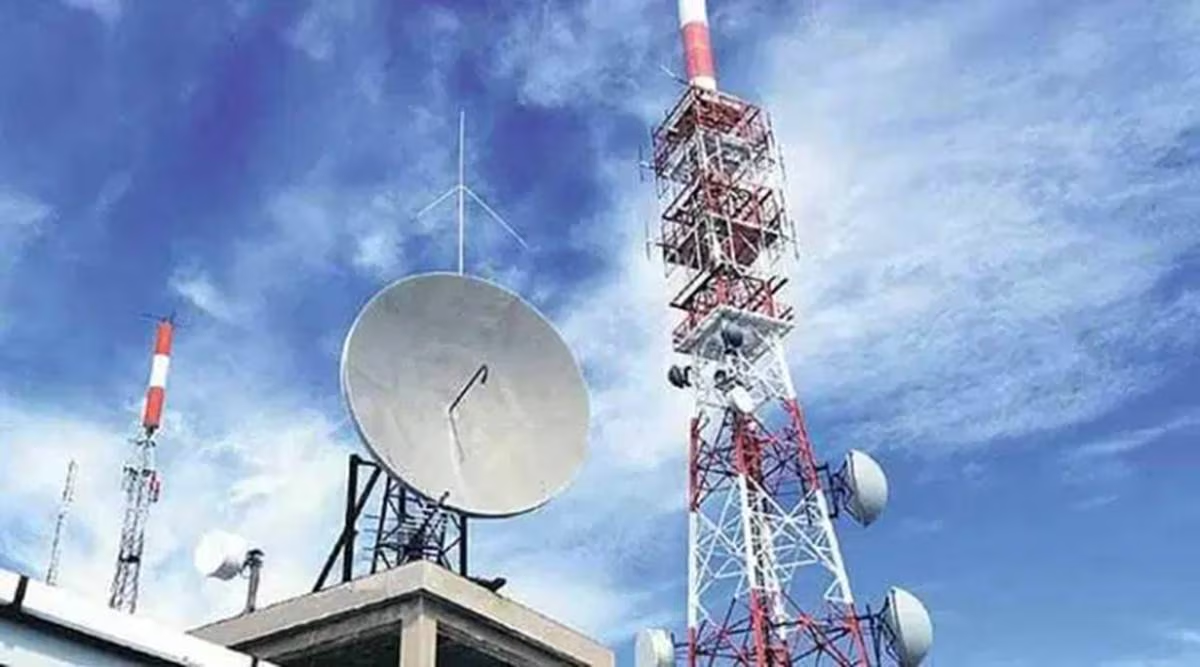

Source: The Indian Express

# Load Dataset

In [21]:
import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [22]:
import pandas as pd
import os

# Assuming the CSV file is named 'WA_Fn-UseC_-Telco-Customer-Churn.csv' inside the downloaded directory
csv_file_path = os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Load the dataset into a pandas DataFrame
df = pd.read_csv(csv_file_path)

display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
# Check for missing values in the DataFrame
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

,0


# Data Preprocessing

- Fill NaN values
- Convert all values to numerical values and one-hot encoding

In [24]:
# Convert 'TotalCharges' to numeric, coercing errors will turn non-numeric values into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill any NaN values in 'TotalCharges' that resulted from coercion (e.g., empty strings) with 0 or the mean/median
# For correlation analysis, dropping these rows or filling with 0 if they represent no charges is common.
# Here, we'll fill with 0, assuming 'TotalCharges' was empty for new customers with no charges yet.
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Convert 'Churn' column to numerical (0 for No, 1 for Yes)
df['Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})

display(df.head())

/tmp/ipykernel_4259/3899429753.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [25]:
import numpy as np

# Drop 'customerID' as it is a unique identifier and not a feature for the model
df_processed = df.drop(columns=['customerID'])

# Select categorical columns for one-hot encoding, excluding 'Churn' (which is already numerical)
categorical_cols = df_processed.select_dtypes(include='object').columns.tolist()

# Perform one-hot encoding
df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

print("DataFrame after one-hot encoding:")
display(df_encoded.head())

DataFrame after one-hot encoding:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [26]:
import numpy as np

# Select categorical columns for one-hot encoding, excluding 'customerID' and 'Churn'
# 'customerID' is unique for each customer and not a feature that impacts churn directly in this context
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Perform one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame after one-hot encoding:")
display(df_encoded.head())

DataFrame after one-hot encoding:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


### Regression Analysis with Regularization (Lasso and Ridge)

To build a predictive model for churn and apply regularization, we need to perform the following steps:
1.  **Define Features (X) and Target (y)**: Separate the dataset into independent variables (features) and the dependent variable (target).
2.  **Split Data**: Divide the data into training and testing sets to evaluate model performance on unseen data.
3.  **Feature Scaling**: Standardize numerical features to ensure they contribute equally to the model, which is crucial for regularization methods.
4.  **Model Training (Lasso and Ridge)**: Train Lasso and Ridge regression models.
5.  **Model Evaluation**: Assess the performance of the models using metrics like accuracy, precision, recall, and F1-score for classification problems.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Lasso, Ridge
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define features (X) and target (y)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled successfully.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Data split and scaled successfully.
X_train_scaled shape: (5634, 7072)
X_test_scaled shape: (1409, 7072)


#### Lasso Regression

Lasso (Least Absolute Shrinkage and Selection Operator) regression adds a penalty equal to the absolute value of the magnitude of coefficients. This type of regularization can lead to some coefficients being exactly zero, effectively performing feature selection.

In [31]:
# Lasso Regression (using Logistic Regression for classification as 'Churn' is binary)
# Note: Lasso and Ridge are typically for linear regression. For binary classification like churn,
# we often use Logistic Regression with L1 (Lasso) or L2 (Ridge) penalties.

# Lasso (L1 penalty) Logistic Regression
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Evaluate Lasso Model
accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
precision_lasso = precision_score(y_test, y_pred_lasso)
recall_lasso = recall_score(y_test, y_pred_lasso)
f1_lasso = f1_score(y_test, y_pred_lasso)

print("Lasso Regression Model Performance:")
print(f"Accuracy: {accuracy_lasso:.4f}")
print(f"Precision: {precision_lasso:.4f}")
print(f"Recall: {recall_lasso:.4f}")
print(f"F1-Score: {f1_lasso:.4f}")

Lasso Regression Model Performance:
Accuracy: 0.8162
Precision: 0.6926
Recall: 0.5496
F1-Score: 0.6129


#### XGBoost Classifier

XGBoost is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework. XGBoost provides a parallel tree boosting (also known as GBDT, GBM) that solves many data science problems in a fast and accurate way.

In [33]:
import xgboost as xgb

# Initialize and train the XGBoost Classifier
# Using use_label_encoder=False and eval_metric='logloss' to avoid future warnings
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluate XGBoost Model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("XGBoost Classifier Model Performance:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:01:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier Model Performance:
Accuracy: 0.7913
Precision: 0.6270
Recall: 0.5228
F1-Score: 0.5702


#### Ridge Regression

Ridge regression adds a penalty equal to the square of the magnitude of coefficients. This helps to reduce model complexity and prevent overfitting by shrinking the coefficients towards zero, but it rarely sets them to exactly zero.

In [32]:
# Ridge (L2 penalty) Logistic Regression
ridge_model = LogisticRegression(penalty='l2', solver='liblinear', C=0.1, random_state=42)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Evaluate Ridge Model
accuracy_ridge = accuracy_score(y_test, y_pred_ridge)
precision_ridge = precision_score(y_test, y_pred_ridge)
recall_ridge = recall_score(y_test, y_pred_ridge)
f1_ridge = f1_score(y_test, y_pred_ridge)

print("Ridge Regression Model Performance:")
print(f"Accuracy: {accuracy_ridge:.4f}")
print(f"Precision: {precision_ridge:.4f}")
print(f"Recall: {recall_ridge:.4f}")
print(f"F1-Score: {f1_ridge:.4f}")

Ridge Regression Model Performance:
Accuracy: 0.8077
Precision: 0.7125
Recall: 0.4584
F1-Score: 0.5579


### Neural Network Model with L2 Regularization

Let's implement a simple neural network with two dense layers, ReLU activation, and L2 regularization to predict customer churn. We'll use the preprocessed and scaled data.

In [46]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

# Define the neural network model
model = Sequential([
    Dense(128, activation='relu', kernel_regularizer=l2(0.1), input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2), # Add dropout layer with a rate of 0.3
    Dense(128, activation='relu', kernel_regularizer=l2(0.1)),
    Dropout(0.2), # Add another dropout layer
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
print("Neural Network Model Summary:")
model.summary()

Neural Network Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 128)            │       905,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 921,985 (3.52 MB)

 Trainable params: 921,985 (3.52 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
from tensorflow.keras.callbacks import EarlyStopping

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,  # Increase epochs as early stopping will stop training when appropriate
    batch_size=32, # You can adjust the batch size
    validation_split=0.2, # Use 20% of training data for validation
    callbacks=[early_stopping] # Add the early stopping callback
)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

# Get predictions for F1-Score calculation
y_pred_nn_prob = model.predict(X_test_scaled)
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int)

f1_nn = f1_score(y_test, y_pred_nn)

print(f"\nNeural Network Test Accuracy: {accuracy:.4f}")
print(f"Neural Network Test Loss: {loss:.4f}")
print(f"Neural Network F1-Score: {f1_nn:.4f}")

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9907 - loss: 0.3235 - val_accuracy: 0.8021 - val_loss: 0.7979
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9887 - loss: 0.3294 - val_accuracy: 0.7986 - val_loss: 0.7947
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9916 - loss: 0.3258 - val_accuracy: 0.7755 - val_loss: 0.8043
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9893 - loss: 0.3261 - val_accuracy: 0.7950 - val_loss: 0.7715
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9911 - loss: 0.3042 - val_accuracy: 0.8012 - val_loss: 0.7371
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9920 - loss: 0.2962 - val_accuracy: 0.8075 - val_loss: 0.7456
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9925 - loss: 0.2951 - val_accuracy: 0.7853 - val_loss: 0.7989
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9909 - loss: 0.2959 - val_accu

### Confusion Matrix Visualization

Let's visualize the confusion matrix for each model to get a clearer picture of their classification performance, specifically how well they identify churned vs. non-churned customers.

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


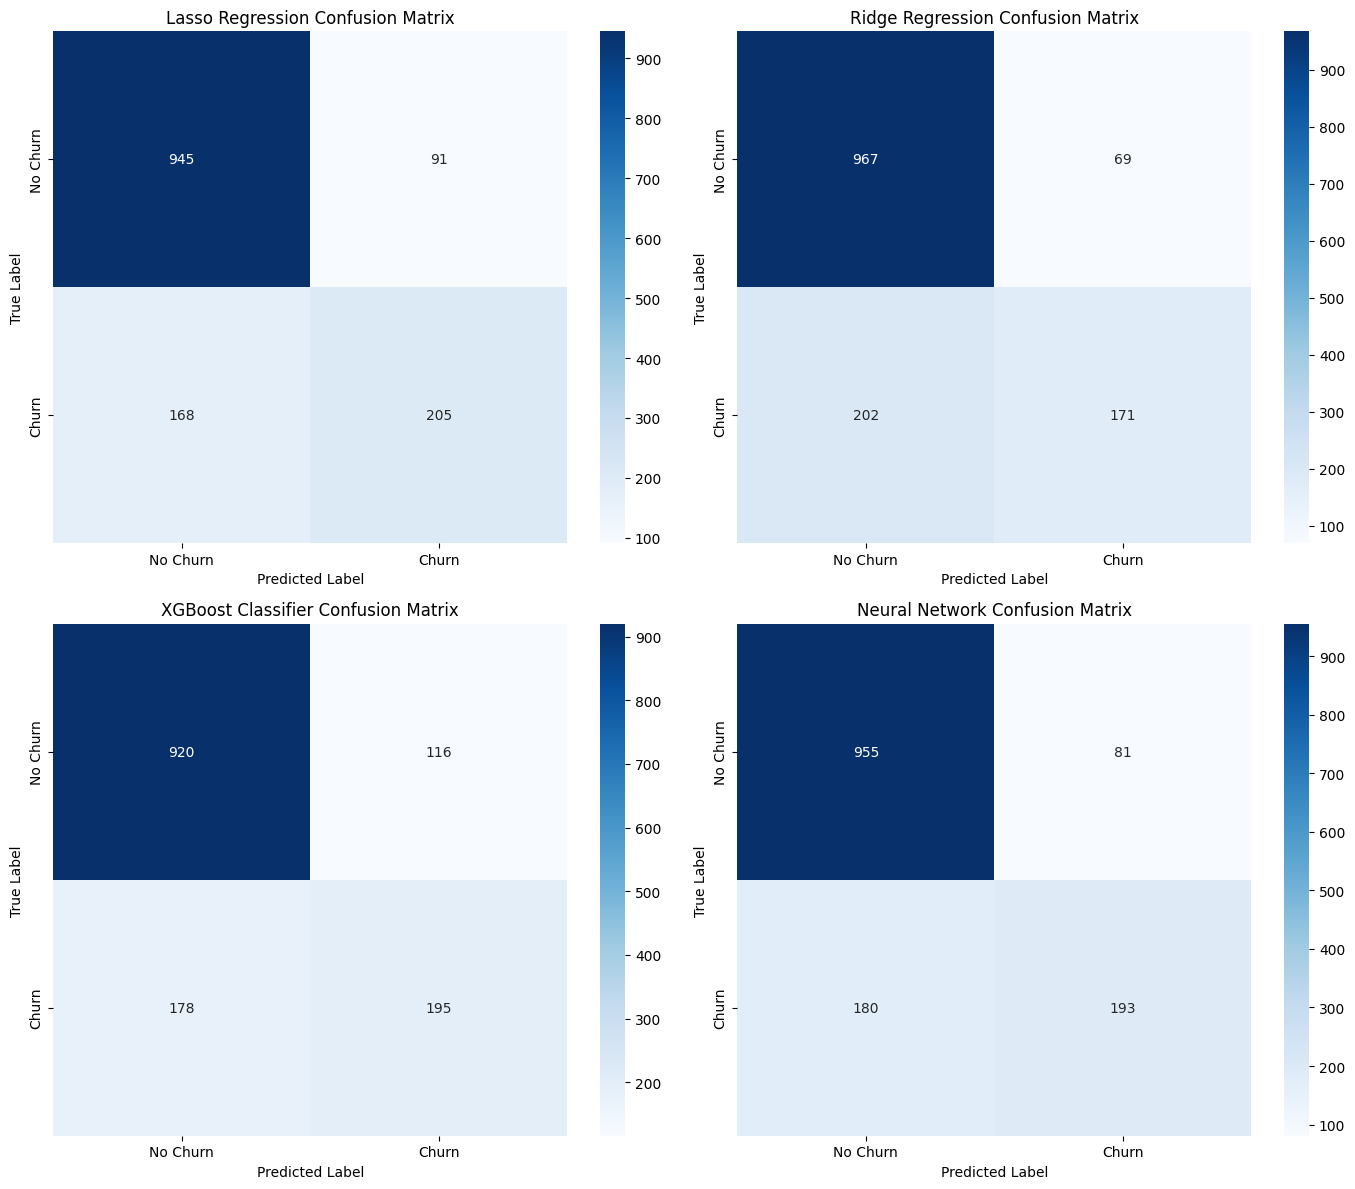

In [50]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions for the Neural Network for confusion matrix
y_pred_nn_prob = model.predict(X_test_scaled)
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int)

models = {
    'Lasso Regression': y_pred_lasso,
    'Ridge Regression': y_pred_ridge,
    'XGBoost Classifier': y_pred_xgb,
    'Neural Network': y_pred_nn
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()
